## Some text

In [9]:
import sys
from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent.parent if Path.cwd().name == "analysis" else Path.cwd()))

from config.project_paths import DB_FILES, FIGURES

In [10]:
con = duckdb.connect(str(DB_FILES / "aruba.duckdb"))
flow_df = con.execute("SELECT * FROM annual_country_flow ORDER BY country, year").df()
con.close()

flow_df.head(10)

,country,year,net_balance
0,Aruba/ Neth. Ant.,2015,-404.0
1,Aruba/ Neth. Ant.,2016,-528.0
2,Aruba/ Neth. Ant.,2017,-852.0
3,Aruba/ Neth. Ant.,2018,-713.0
4,Aruba/ Neth. Ant.,2019,-913.0
5,Aruba/ Neth. Ant.,2020,-1168.0
6,Aruba/ Neth. Ant.,2021,-1014.0
7,Aruba/ Neth. Ant.,2022,-991.0
8,Aruba/ Neth. Ant.,2023,-807.0
9,Colombia,2015,292.0


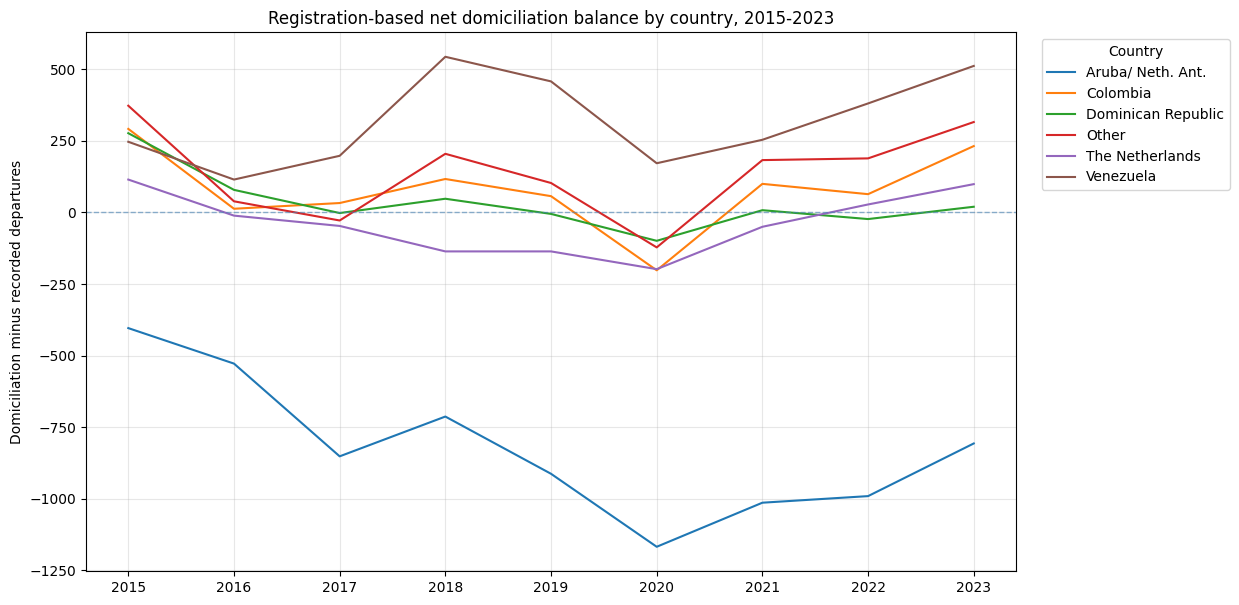

Saved: /home/ggirelli/documents/data-analysis/projects/cbs_aruba/outputs/figures/final_registration_based_net_dom_bal_country.png


In [11]:
fig, ax = plt.subplots(figsize=(12, 7))

for country, group in flow_df.groupby("country"):
    ax.plot(group["year"], group["net_balance"], label=country)

ax.axhline(0, color="steelblue", linestyle="--", linewidth=1, alpha=0.6)
ax.set_title("Registration-based net domiciliation balance by country, 2015-2023")
ax.set_ylabel("Domiciliation minus recorded departures")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(True, alpha=0.3)

fig_path = FIGURES / "final_registration_based_net_dom_bal_country.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", fig_path)
           